# 35 - LSEG/Gemma event-timing circular-shift audit

**Question.** Does Gemma's sparse exact-event schedule identify unusually
valuable trading dates for the Notebook 34 hybrid, after holding the event
frequency, daily long/short counts, FinBERT name ranking, 25% cap, one-session
horizon, and 10 bps/side accounting fixed?

This is an **opened-window retrospective timing-mechanism audit**, not a new
strategy or independent validation. Notebook 34's FinBERT rank substitution
is frozen: Gemma supplies only the 167-session schedule of eligible days and
exact positive/negative name counts; FinBERT ranks the firms assigned to those
slots. The observed schedule is compared with **all 166 non-zero circular
shifts** of that complete schedule. Circular shifts preserve event frequency,
count distribution, and clustering exactly while breaking alignment with the
contemporaneous FinBERT ranks and next-open returns.

The two predeclared rules are the 25%-capped stock book and the unchanged
equal-weight sector projection. Each **timing gate** requires: observed net
mean above the shifted mean, a one-sided exact shift p-value surviving BH-FDR
across the two rules, break-even above 10 bps/side, and nonnegative observed
net Sharpe in both independently initialized chronological halves. Gross mean,
Sharpe, turnover, cost curves, and nearby-versus-distant shifts are
diagnostics. No shift distance, threshold, cap, count, or rule is selected
from returns.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
    sector_project_targets,
)
from sentiment_benchmark.strategy_research.ledger import run_open_to_open_ledger  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    PositionTarget,
    TargetPortfolio,
)

COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
SINGLE_NAME_CAP = 0.25
INITIAL_NAV = 1_000_000.0
RULES = ("capacity_capped", "between_sector")

AGGREGATE_DIR = REPO_ROOT / "final_experiments/outputs/13_lseg_44_gemma_robustness"
GEMMA_PATH = AGGREGATE_DIR / "gemma4_26b_firm_open_aggregators.parquet"
FINBERT_PATH = AGGREGATE_DIR / "finbert_firm_open_aggregators.parquet"
NOTEBOOK34_MANIFEST = (
    REPO_ROOT
    / "final_experiments/outputs/34_lseg_gemma_finbert_matched_count_substitution/manifest.json"
)
PRICE_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/35_lseg_gemma_event_timing_circular_shift"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Paired original-33 inputs and exact returns

No licensed headline text is loaded. The scorer inputs are the aggregate
firm-open panels already validated in Notebook 13.

In [2]:
sector_members = {sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()}
original_symbols = tuple(symbol for members in sector_members.values() for symbol in members)
sector_by_symbol = {
    symbol: sector for sector, members in sector_members.items() for symbol in members
}
gemma = pd.read_parquet(GEMMA_PATH)
finbert = pd.read_parquet(FINBERT_PATH)
for frame in (gemma, finbert):
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
gemma = gemma.loc[gemma["symbol"].isin(original_symbols)].copy()
finbert = finbert.loc[finbert["symbol"].isin(original_symbols)].copy()
if not gemma[["session_date", "symbol"]].equals(finbert[["session_date", "symbol"]]):
    raise ValueError("paired scorer panels are not row-aligned")
if gemma.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate scorer rows")

prices = pd.read_csv(PRICE_PATH, parse_dates=["session_date"])
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
open_wide = prices.pivot(index="session_date", columns="symbol", values="open").sort_index().dropna()
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = tuple(sorted(gemma["symbol"].unique()))
if len(sessions) != 167 or set(symbols) != set(original_symbols):
    raise ValueError("expected 167 sessions and the immutable original 33")
if not gemma.groupby("session_date")["symbol"].nunique().eq(33).all():
    raise ValueError("Gemma panel is incomplete")
if not finbert.groupby("session_date")["symbol"].nunique().eq(33).all():
    raise ValueError("FinBERT panel is incomplete")
if finbert["strongest_event"].isna().any():
    raise ValueError("FinBERT strongest-event ranks must be complete")
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("signal sessions are not consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide):
    raise ValueError("last signal session has no next open")

return_rows: list[OpenToOpenReturn] = []
recomputed_rows: list[dict[str, object]] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    returns = open_wide.loc[next_session, list(symbols)] / open_wide.loc[session, list(symbols)] - 1.0
    for symbol, value in returns.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {"session_date": session, "symbol": symbol, "recomputed": float(value)}
        )
return_audit = gemma[["session_date", "symbol", "raw_open_h1"]].merge(
    pd.DataFrame(recomputed_rows), on=["session_date", "symbol"], validate="1:1"
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("price returns do not reproduce the aggregate panel")
coverage = pd.DataFrame(
    [
        {
            "sessions": len(sessions),
            "companies": len(symbols),
            "sectors": len(sector_members),
            "first_session": sessions.min(),
            "last_session": sessions.max(),
            "nonzero_circular_shifts": len(sessions) - 1,
            "max_return_reproduction_error": float(return_audit["absolute_error"].max()),
        }
    ]
)
display(coverage)

,sessions,companies,sectors,first_session,last_session,nonzero_circular_shifts,max_return_reproduction_error
0,167,33,11,2025-10-27,2026-06-26,166,0.000000


## Frozen schedule and FinBERT rank construction

A shift moves the full Gemma eligibility/count row as one object. FinBERT is
then reranked on the destination date. Inactive rows remain cash.

In [3]:
_, gemma_audit = build_exact_extrema_targets(gemma, single_name_cap=SINGLE_NAME_CAP)
schedule = gemma_audit[
    ["session_date", "eligible", "positive_names", "negative_names"]
].copy()
ranked_symbols_by_session = {
    pd.Timestamp(session): tuple(
        day.sort_values(
            ["strongest_event", "symbol"],
            ascending=[False, True],
            kind="mergesort",
        )["symbol"]
    )
    for session, day in finbert.groupby("session_date", sort=True)
}
if len(ranked_symbols_by_session) != len(sessions) or any(
    len(ranked) != len(symbols) for ranked in ranked_symbols_by_session.values()
):
    raise ValueError("FinBERT rank panel is incomplete")


def shifted_schedule(shift: int) -> pd.DataFrame:
    if not 0 <= shift < len(schedule):
        raise ValueError("shift outside schedule length")
    result = schedule.copy()
    for column in ("eligible", "positive_names", "negative_names"):
        result[column] = np.roll(schedule[column].to_numpy(), shift)
    return result


def build_rank_targets(schedule_rows: pd.DataFrame) -> tuple[TargetPortfolio, ...]:
    required = {"session_date", "eligible", "positive_names", "negative_names"}
    if missing := required - set(schedule_rows.columns):
        raise ValueError(f"schedule missing {sorted(missing)}")
    if not pd.DatetimeIndex(schedule_rows["session_date"]).equals(sessions):
        raise ValueError("schedule sessions are not aligned")
    targets: list[TargetPortfolio] = []
    for schedule_row in schedule_rows.itertuples(index=False):
        ranked = ranked_symbols_by_session[pd.Timestamp(schedule_row.session_date)]
        n_long = int(schedule_row.positive_names)
        n_short = int(schedule_row.negative_names)
        eligible = bool(schedule_row.eligible)
        long_symbols: set[str] = set()
        short_symbols: set[str] = set()
        leg_exposure = 0.0
        if eligible:
            long_symbols = set(ranked[:n_long])
            short_symbols = set(ranked[-n_short:])
            if not n_long or not n_short or long_symbols & short_symbols:
                raise RuntimeError("invalid shifted rank selection")
            leg_exposure = min(
                0.5,
                SINGLE_NAME_CAP * n_long,
                SINGLE_NAME_CAP * n_short,
            )
        weights = {
            symbol: (
                leg_exposure / n_long
                if symbol in long_symbols
                else -leg_exposure / n_short
                if symbol in short_symbols
                else 0.0
            )
            for symbol in symbols
        }
        positions = tuple(
            PositionTarget(
                symbol=symbol,
                action=1.0 if symbol in long_symbols else -1.0 if symbol in short_symbols else 0.0,
                volatility=None,
                raw_weight=weights[symbol],
                target_weight=weights[symbol],
                exclusion_reason=None,
            )
            for symbol in symbols
        )
        vector = np.array([weights[symbol] for symbol in symbols], dtype=float)
        gross = float(np.abs(vector).sum())
        if abs(vector.sum()) > 1e-12 or gross > 1.0 + 1e-12:
            raise RuntimeError("shifted target violates exposure constraints")
        targets.append(
            TargetPortfolio(
                session=str(pd.Timestamp(schedule_row.session_date).date()),
                positions=positions,
                gross_exposure=gross,
                net_exposure=float(vector.sum()),
                long_exposure=float(vector[vector > 0].sum()),
                short_exposure=float(-vector[vector < 0].sum()),
                cash_weight=1.0 - float(vector.sum()),
            )
        )
    return tuple(targets)


observed_capped = build_rank_targets(shifted_schedule(0))
observed_projected, observed_projected_audit = sector_project_targets(
    observed_capped,
    sector_by_symbol=sector_by_symbol,
    single_name_cap=SINGLE_NAME_CAP,
)
schedule_audit = pd.DataFrame(
    [
        {
            "active_sessions": int(schedule["eligible"].sum()),
            "mean_positive_names_active": float(
                schedule.loc[schedule["eligible"], "positive_names"].mean()
            ),
            "mean_negative_names_active": float(
                schedule.loc[schedule["eligible"], "negative_names"].mean()
            ),
            "maximum_positive_names": int(schedule["positive_names"].max()),
            "maximum_negative_names": int(schedule["negative_names"].max()),
            "projected_active_sessions": int(
                observed_projected_audit["projected_gross_exposure"].gt(0).sum()
            ),
        }
    ]
)
display(schedule_audit.T)

,0
active_sessions,70.000000
mean_positive_names_active,1.785714
mean_negative_names_active,1.428571
maximum_positive_names,6.000000
maximum_negative_names,4.000000
projected_active_sessions,68.000000


## Drift-aware observed paths and exact circular-shift null

In [4]:
def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one terminal liquidation")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"]) - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    return intervals


def run_targets(
    targets: tuple[TargetPortfolio, ...],
    *,
    cost_bps: float,
) -> pd.DataFrame:
    full = ledger_rows_to_frame(
        run_open_to_open_ledger(
            targets,
            return_rows,
            cost_rate_per_side=cost_bps / 10_000.0,
            initial_nav_usd=INITIAL_NAV,
            force_final_liquidation=True,
        )
    )
    return fold_final_liquidation(full)


def summarize(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": len(daily),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "total_return_gross": float(np.prod(1.0 + gross) - 1.0),
        "total_return_net": float(equity[-1] - 1.0),
        "max_drawdown": float(np.min(with_start / np.maximum.accumulate(with_start) - 1.0)),
        "mean_turnover": float(turnover / len(daily)),
        "total_turnover": turnover,
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover),
        "cost_bps_per_side": cost_bps,
    }


observed_targets = {
    "capacity_capped": observed_capped,
    "between_sector": observed_projected,
}
observed_daily = {
    rule: run_targets(targets, cost_bps=COST_BPS)
    for rule, targets in observed_targets.items()
}
observed_results = pd.DataFrame(
    [
        {"rule": rule, **summarize(observed_daily[rule], cost_bps=COST_BPS)}
        for rule in RULES
    ]
)

notebook34 = json.loads(NOTEBOOK34_MANIFEST.read_text())
reference34 = pd.DataFrame(notebook34["results"]).set_index(["scorer", "rule"])
for rule in RULES:
    observed = observed_results.set_index("rule").loc[rule]
    reference = reference34.loc[("finbert_rank_substitute", rule)]
    for metric in (
        "mean_gross",
        "mean_net",
        "sharpe_gross",
        "sharpe_net",
        "total_return_net",
        "mean_turnover",
    ):
        if not np.isclose(observed[metric], reference[metric], atol=1e-10):
            raise RuntimeError(f"Notebook 34 reproduction failed for {rule}/{metric}")

shift_rows: list[dict[str, float | int | str]] = []
for shift in range(1, len(sessions)):
    capped = build_rank_targets(shifted_schedule(shift))
    projected = sector_project_targets(
        capped,
        sector_by_symbol=sector_by_symbol,
        single_name_cap=SINGLE_NAME_CAP,
    )[0]
    for rule, targets in zip(RULES, (capped, projected), strict=True):
        daily = run_targets(targets, cost_bps=COST_BPS)
        shift_rows.append(
            {
                "shift": shift,
                "signed_minimum_distance": min(shift, len(sessions) - shift),
                "rule": rule,
                **summarize(daily, cost_bps=COST_BPS),
            }
        )
shift_null = pd.DataFrame(shift_rows)
display(observed_results)
display(shift_null.groupby("rule")[["mean_net", "sharpe_net", "mean_turnover"]].describe())

,rule,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,capacity_capped,167,70,0.001127,0.000680,3.699940,2.271209,0.204584,0.118176,-0.029025,0.446484,74.562862,25.235033,10.000000
1,between_sector,167,68,0.000703,0.000321,3.506912,1.629533,0.123605,0.054256,-0.017270,0.381829,63.765399,18.414185,10.000000


mean_net                                                   \
                     count      mean      std       min       25%       50%   
rule                                                                          
between_sector  166.000000 -0.000128 0.000197 -0.000607 -0.000244 -0.000144   
capacity_capped 166.000000  0.000022 0.000306 -0.000720 -0.000171  0.000015   

                                   sharpe_net                               \
                      75%      max      count      mean      std       min   
rule                                                                         
between_sector  -0.000006 0.000455 166.000000 -0.650207 0.968293 -3.465090   
capacity_capped  0.000217 0.000926 166.000000  0.042401 1.003566 -2.662864   

                                                       mean_turnover           \
                      25%       50%       75%      max         count     mean   
rule                                                                            
between_sector  -1.292585 -0.697662 -0.027943 1.989945    166.000000 0.411769   
capacity_capped -0.596546  0.047130  0.753049 2.891056    166.000000 0.458115   

                                                                       
                     std      min      25%      50%      75%      max  
rule                                                                   
between_sector  0.011727 0.374395 0.405132 0.410273 0.419738 0.445864  
capacity_capped 0.007965 0.435313 0.453081 0.458883 0.463516 0.474093

## Frozen timing gates and diagnostics

The exact one-sided p-value ranks the observed statistic against all 166
non-zero shifts, with the observed arrangement included once in the
denominator. Nearby shifts are reported separately only as a diagnostic.

In [5]:
timing_rows = []
for rule in RULES:
    observed = observed_results.set_index("rule").loc[rule]
    null = shift_null.loc[shift_null["rule"].eq(rule)]
    observed_mean = float(observed["mean_net"])
    observed_gross = float(observed["mean_gross"])
    p_net = float((1 + null["mean_net"].ge(observed_mean).sum()) / (len(null) + 1))
    p_gross = float((1 + null["mean_gross"].ge(observed_gross).sum()) / (len(null) + 1))
    p_sharpe = float((1 + null["sharpe_net"].ge(observed["sharpe_net"]).sum()) / (len(null) + 1))
    nearby = null.loc[null["signed_minimum_distance"].le(10)]
    distant = null.loc[null["signed_minimum_distance"].gt(10)]
    timing_rows.append(
        {
            "rule": rule,
            "observed_mean_net": observed_mean,
            "shift_null_mean_net": float(null["mean_net"].mean()),
            "shift_null_ci_low_net": float(null["mean_net"].quantile(0.025)),
            "shift_null_ci_high_net": float(null["mean_net"].quantile(0.975)),
            "p_one_sided_net": p_net,
            "p_one_sided_gross": p_gross,
            "p_one_sided_sharpe": p_sharpe,
            "observed_percentile_net": float(null["mean_net"].lt(observed_mean).mean()),
            "nearby_shift_mean_net": float(nearby["mean_net"].mean()),
            "distant_shift_mean_net": float(distant["mean_net"].mean()),
        }
    )
timing_inference = pd.DataFrame(timing_rows)
timing_inference["bh_reject_net_q05"] = benjamini_hochberg(
    timing_inference["p_one_sided_net"].tolist(), q=0.05
)

temporal34 = pd.DataFrame(notebook34["temporal"])
half_sharpes = (
    temporal34.loc[temporal34["scorer"].eq("finbert_rank_substitute")]
    .set_index(["period", "rule"])["sharpe_net"]
)
gate_rows = []
for row in timing_inference.itertuples(index=False):
    observed = observed_results.set_index("rule").loc[row.rule]
    first_half = float(half_sharpes.loc[("first_half", row.rule)])
    second_half = float(half_sharpes.loc[("second_half", row.rule)])
    gate_rows.append(
        {
            "rule": row.rule,
            "timing_gate": bool(
                row.observed_mean_net > row.shift_null_mean_net
                and row.bh_reject_net_q05
                and observed["breakeven_bps_per_side"] > COST_BPS
                and first_half >= 0
                and second_half >= 0
            ),
            "observed_minus_shift_mean_bps_session": float(
                (row.observed_mean_net - row.shift_null_mean_net) * 10_000
            ),
            "p_one_sided_net": row.p_one_sided_net,
            "bh_reject_net_q05": bool(row.bh_reject_net_q05),
            "p_one_sided_gross": row.p_one_sided_gross,
            "p_one_sided_sharpe": row.p_one_sided_sharpe,
            "first_half_net_sharpe": first_half,
            "second_half_net_sharpe": second_half,
            "breakeven_bps_per_side": float(observed["breakeven_bps_per_side"]),
        }
    )
gates = pd.DataFrame(gate_rows)

cost_rows = []
for cost in COST_GRID:
    for rule in RULES:
        daily = run_targets(observed_targets[rule], cost_bps=cost)
        cost_rows.append({"rule": rule, **summarize(daily, cost_bps=cost)})
cost_curve = pd.DataFrame(cost_rows)
display(timing_inference)
display(gates)

,rule,observed_mean_net,shift_null_mean_net,shift_null_ci_low_net,shift_null_ci_high_net,p_one_sided_net,p_one_sided_gross,p_one_sided_sharpe,observed_percentile_net,nearby_shift_mean_net,distant_shift_mean_net,bh_reject_net_q05
0,capacity_capped,0.000680,0.000022,-0.000524,0.000562,0.023952,0.023952,0.011976,0.981928,-0.000095,0.000038,True
1,between_sector,0.000321,-0.000128,-0.000524,0.000230,0.029940,0.029940,0.017964,0.975904,-0.000205,-0.000117,True


,rule,timing_gate,observed_minus_shift_mean_bps_session,p_one_sided_net,bh_reject_net_q05,p_one_sided_gross,p_one_sided_sharpe,first_half_net_sharpe,second_half_net_sharpe,breakeven_bps_per_side
0,capacity_capped,True,6.584826,0.023952,True,0.023952,0.011976,3.363973,0.971511,25.235033
1,between_sector,True,4.489645,0.029940,True,0.029940,0.017964,2.221522,1.065356,18.414185


## Figures

findfont: Failed to find font weight medium, now using 400.


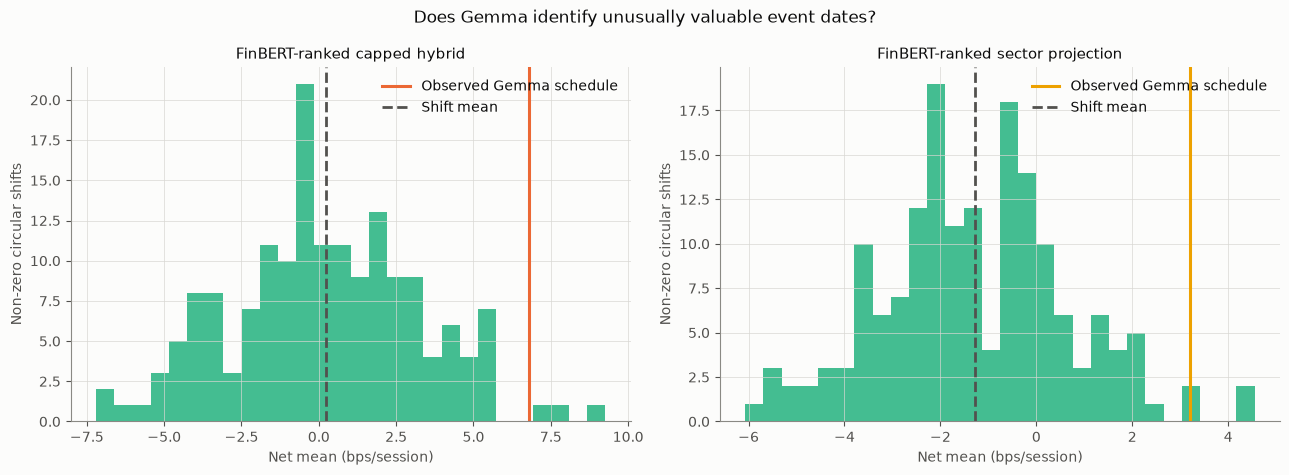

In [6]:
colours = {"capacity_capped": CATEGORICAL[1], "between_sector": CATEGORICAL[3]}
labels = {
    "capacity_capped": "FinBERT-ranked capped hybrid",
    "between_sector": "FinBERT-ranked sector projection",
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for axis, rule in zip(axes, RULES, strict=True):
    null = shift_null.loc[shift_null["rule"].eq(rule)]
    observed = observed_results.set_index("rule").loc[rule]
    axis.hist(null["mean_net"] * 10_000, bins=28, color=CATEGORICAL[2], alpha=0.82)
    axis.axvline(
        observed["mean_net"] * 10_000,
        color=colours[rule],
        linewidth=2.2,
        label="Observed Gemma schedule",
    )
    axis.axvline(
        null["mean_net"].mean() * 10_000,
        color=INK["reference"],
        linestyle="--",
        label="Shift mean",
    )
    axis.set_xlabel("Net mean (bps/session)")
    axis.set_ylabel("Non-zero circular shifts")
    axis.set_title(labels[rule])
    axis.legend(loc="best")
fig.suptitle("Does Gemma identify unusually valuable event dates?")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "timing_shift_null.png", dpi=170, bbox_inches="tight")
plt.show()

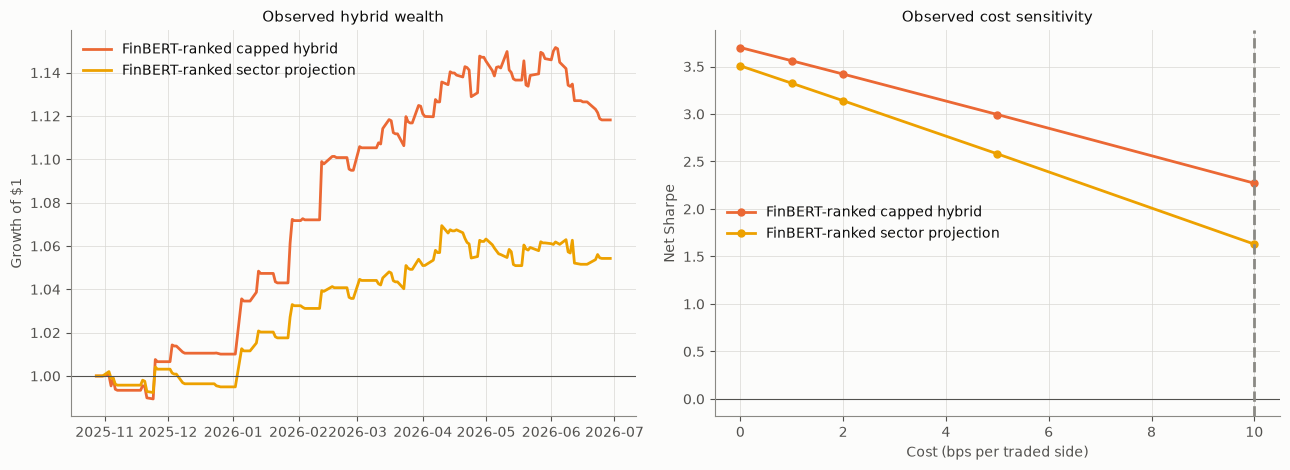

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for rule in RULES:
    daily = observed_daily[rule]
    axes[0].plot(
        daily["return_end_date"],
        (1.0 + daily["net_return"]).cumprod(),
        color=colours[rule],
        label=labels[rule],
    )
    line = cost_curve.loc[cost_curve["rule"].eq(rule)]
    axes[1].plot(
        line["cost_bps_per_side"],
        line["sharpe_net"],
        marker="o",
        color=colours[rule],
        label=labels[rule],
    )
axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("Observed hybrid wealth")
axes[0].legend(loc="best")
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].axvline(COST_BPS, color=INK["muted"], linestyle="--")
axes[1].set_xlabel("Cost (bps per traded side)")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Observed cost sensitivity")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "observed_equity_and_costs.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate outputs and decision

In [8]:
coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
schedule.to_csv(OUTPUT_DIR / "gemma_event_count_schedule.csv", index=False)
schedule_audit.to_csv(OUTPUT_DIR / "schedule_audit.csv", index=False)
observed_projected_audit.to_csv(OUTPUT_DIR / "observed_projected_audit.csv", index=False)
observed_results.to_csv(OUTPUT_DIR / "observed_results.csv", index=False)
shift_null.to_csv(OUTPUT_DIR / "circular_shift_null.csv", index=False)
timing_inference.to_csv(OUTPUT_DIR / "timing_inference.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for rule, daily in observed_daily.items():
    daily.to_parquet(OUTPUT_DIR / f"{rule}_observed_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "RETROSPECTIVE_OPENED_WINDOW_EXACT_CIRCULAR_SHIFT_TIMING_AUDIT",
    "notebook": "35_lseg_gemma_event_timing_circular_shift.ipynb",
    "git_commit_at_execution": git_commit,
    "input": {
        "gemma_aggregate_panel": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "finbert_aggregate_panel": str(FINBERT_PATH.relative_to(REPO_ROOT)),
        "notebook34_manifest": str(NOTEBOOK34_MANIFEST.relative_to(REPO_ROOT)),
        "price_path": str(PRICE_PATH.relative_to(REPO_ROOT)),
        "licensed_headline_text_loaded": False,
    },
    "coverage": json.loads(coverage.to_json(orient="records", date_format="iso"))[0],
    "specification": {
        "observed_rule": "Gemma exact-event schedule/counts plus FinBERT within-day ranks",
        "null": "all 166 non-zero circular shifts of the complete 167-session schedule",
        "preserved_by_shift": [
            "event frequency",
            "positive/negative count distribution",
            "event clustering",
            "FinBERT rank construction",
            "25% cap",
            "one-session horizon",
            "10 bps/side cost and drift-aware ledger",
        ],
        "rules": list(RULES),
        "multiplicity": "two one-sided net-mean timing tests; BH-FDR q=0.05",
        "final_liquidation": True,
    },
    "schedule_audit": json.loads(schedule_audit.to_json(orient="records"))[0],
    "observed_results": json.loads(observed_results.to_json(orient="records")),
    "timing_inference": json.loads(timing_inference.to_json(orient="records")),
    "gates": json.loads(gates.to_json(orient="records")),
    "limitations": [
        "Notebook 34's opened result directly motivated this timing audit",
        "the same eight-month LSEG return window is already opened",
        "circular shifts assume approximate stationarity and wrap the sample endpoints",
        "Gemma controls event dates and counts while FinBERT controls name ranking",
        "the null preserves the schedule but not calendar-specific event intensity regimes",
        "projected gross exposure can differ across shifts because selected sectors differ",
        "the result is a timing-mechanism diagnostic, not a deployable policy",
        "human validation of full-corpus Gemma labels remains open",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_OPENED_WINDOW_EXACT_CIRCULAR_SHIFT_TIMING_AUDIT",
  "notebook": "35_lseg_gemma_event_timing_circular_shift.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "input": {
    "gemma_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "finbert_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/finbert_firm_open_aggregators.parquet",
    "notebook34_manifest": "final_experiments/outputs/34_lseg_gemma_finbert_matched_count_substitution/manifest.json",
    "price_path": "Data/derived/prices/lseg_us_sector_33_8m.csv",
    "licensed_headline_text_loaded": false
  },
  "coverage": {
    "sessions": 167,
    "companies": 33,
    "sectors": 11,
    "first_session": "2025-10-27T00:00:00.000",
    "last_session": "2026-06-26T00:00:00.000",
    "nonzero_circular_shifts": 166,
    "max_return_reproduction_error": 0.0
  },
  "specification": {
    "obse

## Decision

Both predeclared **Gemma event-timing gates pass**. For the FinBERT-ranked
capped hybrid, the observed net mean is **6.802 bps/session**, versus **0.217
bps/session** across all 166 non-zero shifts. The observed-minus-shift-mean
advantage is **6.585 bps/session**; the observed result is above **98.19%** of
shifted schedules. Its exact one-sided p-value is **0.0240** for both net and
gross mean and **0.0120** for net Sharpe. The net-mean test survives the
two-rule BH family.

The FinBERT-ranked sector projection also passes. Observed net mean is **3.213
bps/session**, versus a shifted mean of **-1.277 bps**; the advantage is
**4.490 bps/session** and the observed schedule is above **97.59%** of shifts.
Exact one-sided p-values are **0.0299** for net/gross mean and **0.0180** for
net Sharpe, with the net test again surviving BH. The observed values sit
beyond the shifted 95% ranges: capped shift mean range **[-5.243,+5.615]
bps/session** and projected range **[-5.242,+2.295]**.

The result is not driven by only distant realignments. Shifts within ten
sessions average **-0.948 bps/session** capped and **-2.053 bps/session**
projected, versus **+0.377** and **-1.171** for more distant shifts. The
observed rules also retain the previously frozen implementation checks:
capped/projected break-even costs are **25.24/18.41 bps/side**, and their
independently initialized first/second-half net Sharpes are **3.364/0.972**
and **2.222/1.065**.

This materially sharpens the strategy story. Notebook 34 showed that FinBERT
ranking is at least competitive with Gemma for choosing names; this notebook
shows that the **Gemma exact-event schedule contributes unusual timing** even
after event frequency, daily counts, clustering, name-ranking rule, cap,
horizon, and costs are fixed. The capped hybrid is therefore the best current
new-date candidate: Gemma decides **when**, FinBERT ranks **what**, and the 25%
cap controls concentration.

It is still not validated alpha. Circular shifting assumes approximate
stationarity, wraps the endpoints, and operates on the same opened eight-month
window that motivated the hybrid. Preserve both successful timing tests, do
not tune a shift distance or scorer blend, and require a frozen direct
cash-alpha audit plus genuinely new 26B-scored dates before promotion.